# Chunked inference blends degraded chunk tails into every seam

Chunked runs of Apollo carry a faint dropout at every chunk boundary. This notebook locates the
cause using only this repository's code and its public 6 s fixture, tiled to 20 s.

Two findings:

1. Apollo's output for a chunk is **bit-identical** no matter where the chunk boundaries fall —
   except near the chunk's edges. The last ~0.5 s is wrong at full signal level; the first ~0.5 s is
   mildly wrong (~−60 dB), which is expected where backward context is missing.
2. The overlap crossfade in `run_model` blends that degraded tail into the output at every seam.

In [1]:
import sys

sys.path.insert(0, ".")

import matplotlib.pyplot as plt
import numpy as np
import torch

import inference
import look2hear.models

SR = inference.SAMPLE_RATE
DEVICE = inference.select_device("mps")

checkpoint = inference.resolve_checkpoint("JusperLee/Apollo")
model = look2hear.models.BaseModel.from_pretrain(
    str(checkpoint), sr=SR, win=20, feature_dim=256, layer=6
).to(DEVICE).eval()

fixture, _ = inference.load_audio("asserts/input_wav.wav")     # (1, 2, 6 s)
clip = torch.cat([fixture] * 4, dim=-1)[..., : 20 * SR]        # tiled to 20 s


def restore(start_s, length_s=10.0):
    """Apollo on one chunk of `clip`. Returns (channels, samples) numpy."""
    a, b = int(start_s * SR), int((start_s + length_s) * SR)
    with torch.inference_mode():
        out = model(clip[..., a:b].to(DEVICE)).detach().cpu()
    return out.squeeze(0).numpy()


def level_db(x, frame_s=0.02):
    """RMS level in short frames, in dB. One value per frame."""
    mono = x.mean(0)
    n = int(frame_s * SR)
    frames = mono[: len(mono) // n * n].reshape(-1, n)
    return 20 * np.log10(np.sqrt((frames ** 2).mean(axis=1)) + 1e-9)


print(f"device {DEVICE}, clip {clip.shape[-1] / SR:.0f}s")

/Users/zakariazbitou/Projects/Apollo/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 47] 80


device mps, clip 20s


## 1. The phenomenon

Two chunks that share the region 7–15 s: one covering 5–15 s, one covering 7–17 s. Subtract their
predictions of the shared region. If chunk placement did not matter, the difference would be zero
everywhere.

/Users/zakariazbitou/Projects/Apollo/.venv/lib/python3.10/site-packages/torch/functional.py:681: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [2, 1001, 442]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse an out tensor t by resizing it, inplace, to zero elements with t.resize_(0). (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/Resize.cpp:38.)
  return _VF.stft(  # type: ignore[attr-defined]


/Users/zakariazbitou/Projects/Apollo/./look2hear/models/apollo.py:296: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [2, 1001, 882]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse an out tensor t by resizing it, inplace, to zero elements with t.resize_(0). (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/Resize.cpp:38.)
  output = torch.istft(est_spec, n_fft=self.win, hop_length=self.stride,


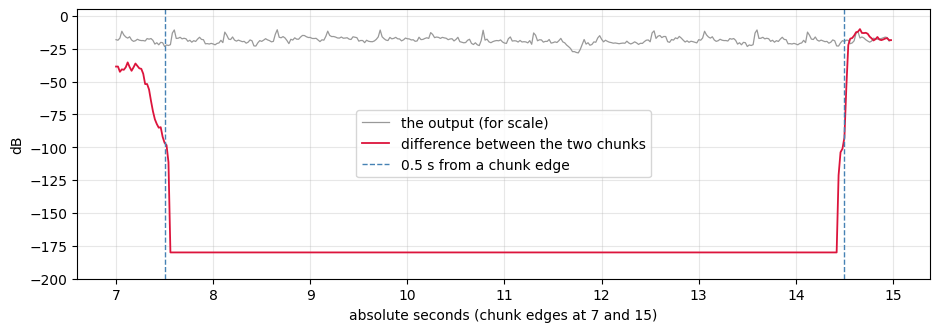

head of the 7-17 chunk (7.0-7.5 s)       -25.7 dB vs the output
middle (7.5-14.5 s)                     -161.3 dB vs the output
tail of the 5-15 chunk (14.5-15 s)        +0.8 dB vs the output


In [2]:
w1 = restore(start_s=5.0)          # covers  5-15 s; the shared region is its tail end
w2 = restore(start_s=7.0)          # covers  7-17 s; the shared region is its head end

shared_w1 = w1[:, int(2.0 * SR) : int(10.0 * SR)]     # absolute 7-15 s
shared_w2 = w2[:, : int(8.0 * SR)]

difference_db = level_db(shared_w1 - shared_w2)
signal_db = level_db(shared_w1)
t = 7.0 + np.arange(len(difference_db)) * 0.02

fig, ax = plt.subplots(figsize=(11, 3.5))
ax.plot(t, signal_db, lw=0.9, color="0.6", label="the output (for scale)")
ax.plot(t, difference_db, lw=1.3, color="crimson", label="difference between the two chunks")
ax.axvline(7.5, color="steelblue", ls="--", lw=1, label="0.5 s from a chunk edge")
ax.axvline(14.5, color="steelblue", ls="--", lw=1)
ax.set(xlabel="absolute seconds (chunk edges at 7 and 15)", ylabel="dB", ylim=(-200, 5))
ax.legend(loc="center")
ax.grid(alpha=0.3)
plt.show()

for name, lo, hi in [("head of the 7-17 chunk (7.0-7.5 s)", 7.0, 7.5),
                     ("middle (7.5-14.5 s)", 7.5, 14.5),
                     ("tail of the 5-15 chunk (14.5-15 s)", 14.5, 15.0)]:
    m = (t >= lo) & (t < hi)
    print(f"{name:38s} {np.median(difference_db[m] - signal_db[m]):+7.1f} dB vs the output")

Across the middle the difference is the epsilon of the log — the two chunks are bit-identical, so
chunk placement is irrelevant there. Near the edges they part company: mildly at a chunk's head,
catastrophically at a chunk's tail, where the difference reaches the level of the output itself.

The trailing ~0.5 s of every chunk is not a slightly worse prediction. It is different audio.

## 2. What `run_model` does with that tail

With `chunk_samples` of 6 s and `overlap_samples` of 1 s (the documented example), chunks start at
0, 5, 10, 15 s. At each overlap the earlier chunk contributes its **tail** — the degraded part —
fading out across the full second while the later chunk fades in. The crossfade averages good audio
with bad.

To score it: at the centre of each overlap, the reference is a fresh chunk **centred** on that
instant, which is the most context Apollo can be given for it.

In [3]:
with torch.inference_mode():
    chunked_out = inference.run_model(
        model, clip, DEVICE,
        chunk_samples=6 * SR,
        overlap_samples=1 * SR,
    ).squeeze(0).numpy()


def error_vs_centred_db(render, at_s, span_s=1.0):
    """Distance from a chunk centred on `at_s`, in dB relative to it."""
    clip_s = clip.shape[-1] / SR
    start = min(max(at_s - 5.0, 0.0), clip_s - 10.0)       # window inside the clip
    centred = restore(start_s=start)
    off, half = int((at_s - start) * SR), int(span_s * SR / 2)
    truth = centred[:, off - half : off + half]
    seg = render[:, int(at_s * SR) - half : int(at_s * SR) + half]
    n = min(truth.shape[1], seg.shape[1])
    diff = truth[:, :n] - seg[:, :n]
    if not np.any(diff):
        return None
    return (20 * np.log10(np.sqrt((diff ** 2).mean()))
            - 20 * np.log10(np.sqrt((truth[:, :n] ** 2).mean())))


print("chunked output vs a centred prediction, at each overlap centre:")
for at_s in (5.5, 10.5, 15.5):
    err = error_vs_centred_db(chunked_out, at_s=at_s)
    shown = "identical" if err is None else f"{err:6.1f} dB"
    print(f"  {at_s:5.1f}s   {shown}")

/Users/zakariazbitou/Projects/Apollo/.venv/lib/python3.10/site-packages/torch/functional.py:681: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [2, 601, 442]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse an out tensor t by resizing it, inplace, to zero elements with t.resize_(0). (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/Resize.cpp:38.)
  return _VF.stft(  # type: ignore[attr-defined]


/Users/zakariazbitou/Projects/Apollo/./look2hear/models/apollo.py:296: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [2, 601, 882]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse an out tensor t by resizing it, inplace, to zero elements with t.resize_(0). (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/Resize.cpp:38.)
  output = torch.istft(est_spec, n_fft=self.win, hop_length=self.stride,


chunked output vs a centred prediction, at each overlap centre:


    5.5s    -18.5 dB


   10.5s    -12.3 dB


   15.5s    -10.4 dB


Between −18 dB and −10 dB below the music at every seam — audible as a periodic dropout on long
renders, recurring every `chunk − overlap` seconds.

## 3. The fix

`--chunk-pad-seconds`: each chunk is inferred with that much extra audio on each side, and that
part of the output is dropped. The wrong edges still happen — they never reach the output. The
default of 0 keeps the previous output bit for bit; 1.0 is past the measured wrong-edge extent
(about 0.5 s) and gives clean seams.

## 4. Before and after, against a run with no chunking at all

The reference is the model run **once, on the whole clip, with no chunking code involved** —
produced on a CUDA GPU (an unchunked 20 s pass does not fit this machine) with the loop below, and
committed here as `unchunked_cuda_20s.npy`:

```python
clip = torch.cat([fixture] * 4, dim=-1)[..., : 20 * SR]
full = model(clip.to("cuda")).cpu()          # one call, nothing else
```

Each chunked run on MPS is scored against it as per-frame **signal-to-noise ratio** — the power of
the reference over the power of the difference, in dB, higher is better. Two devices never agree to
the last bit, so the flat parts sit near the CUDA-vs-MPS numeric ceiling (about 70 dB SNR) instead
of at infinity. The padding is real neighboring audio, never silence: the model is trained on audio
that begins abruptly, so the first chunk starts at the raw file start — an early version that
prepended silence dipped hard at 0 s. At the file's end every run, the unchunked one included, is
at a window edge with nothing beyond it, so the dip there says nothing about seams. The shallow
dips near the fixture's tile splices are the two devices disagreeing, not chunking: pads of 1.0
and 2.0 agree with each other past 120 dB there.

/Users/zakariazbitou/Projects/Apollo/.venv/lib/python3.10/site-packages/torch/functional.py:681: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [2, 801, 442]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse an out tensor t by resizing it, inplace, to zero elements with t.resize_(0). (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/Resize.cpp:38.)
  return _VF.stft(  # type: ignore[attr-defined]


/Users/zakariazbitou/Projects/Apollo/./look2hear/models/apollo.py:296: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [2, 801, 882]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse an out tensor t by resizing it, inplace, to zero elements with t.resize_(0). (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/Resize.cpp:38.)
  output = torch.istft(est_spec, n_fft=self.win, hop_length=self.stride,


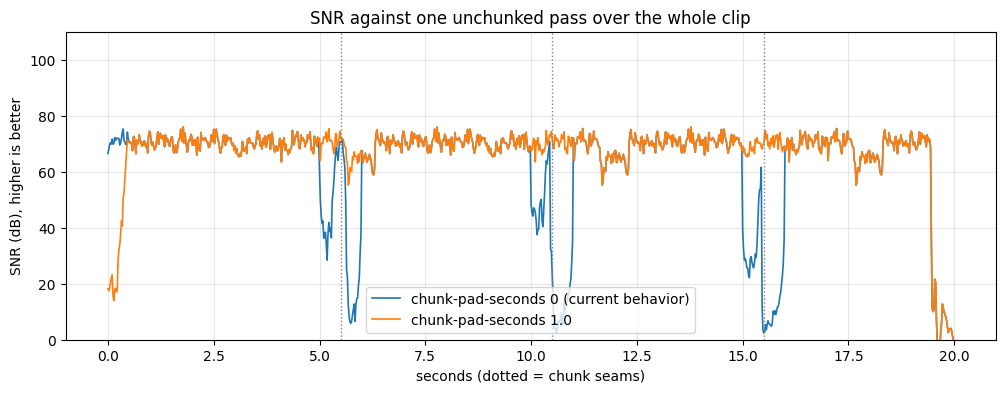

In [4]:
reference = np.load("unchunked_cuda_20s.npy")

runs = {
    "chunk-pad-seconds 0 (current behavior)": 0,
    "chunk-pad-seconds 1.0": SR,
}

fig, ax = plt.subplots(figsize=(12, 4))
for label, pad in runs.items():
    with torch.inference_mode():
        out = inference.run_model(
            model, clip, DEVICE,
            chunk_samples=6 * SR, overlap_samples=1 * SR, chunk_pad_samples=pad,
        ).squeeze(0).numpy()
    n = min(out.shape[1], reference.shape[1])
    snr = level_db(reference[:, :n]) - level_db(reference[:, :n] - out[:, :n])
    ax.plot(np.arange(len(snr)) * 0.02, snr, lw=1.2, label=label)

for seam in (5.5, 10.5, 15.5):
    ax.axvline(seam, ls=":", lw=1, color="0.5")
ax.set(xlabel="seconds (dotted = chunk seams)", ylabel="SNR (dB), higher is better",
       ylim=(0, 110), title="SNR against one unchunked pass over the whole clip")
ax.legend(loc="lower center")
ax.grid(alpha=0.3)
fig.savefig("seam_padding_comparison.png", dpi=130, bbox_inches="tight")
plt.show()